# EdgeAI-ZU4EV — Phase 1A: CIFAR-10 VGG-Lite Training

**Target**: XCZU4EV (88K LUT / 728 DSP / 256 BRAM)  
**Strategy**: VGG-Lite ~28K student + wider teacher + **KD** + **MixUp/CutMix** + **EMA** + **SGD-Cosine**  
**Goal**: test accuracy **≥ 83%**, low overfitting risk

| Stage | Model | Params | Output |
|-------|-------|--------|--------|
| 1 | Teacher 24/32/48 | ~47K | `model_teacher.h5` |
| 2 | Student 16/20/24 | ~22K | `model_fp32.h5` (EMA best) |

---

TF Version: 2.6.0
Numpy Version: 1.19.5


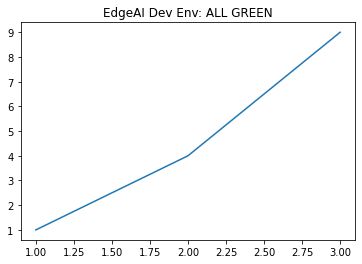

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

print(f"TF Version: {tf.__version__}")
print(f"Numpy Version: {np.__version__}")

plt.plot([1, 2, 3], [1, 4, 9])
plt.title("EdgeAI Dev Env: ALL GREEN")
plt.show()

## 1. Environment Setup

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import confusion_matrix, classification_report
import json

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

# Output directory
os.makedirs('../results', exist_ok=True)
os.makedirs('saved_model', exist_ok=True)

TensorFlow version: 2.6.0
GPU available: True


2026-05-21 10:50:57.356992: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 10:50:57.374119: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 10:50:57.374796: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 2. Data Loading & Preprocessing

Train samples : 50000
Test  samples : 10000
Image shape   : (32, 32, 3)


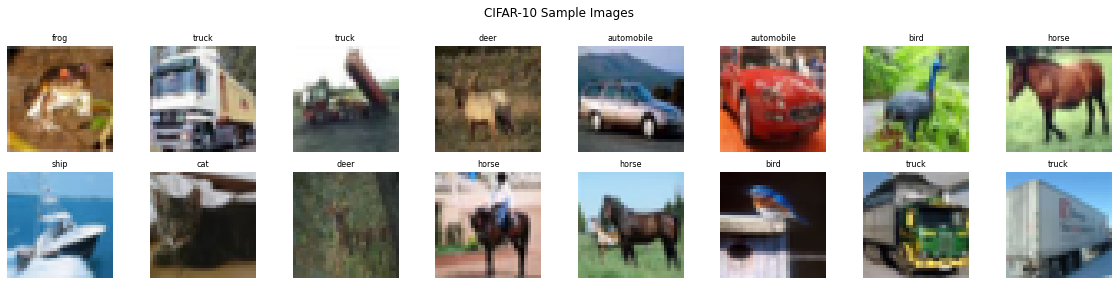

In [3]:
# CIFAR-10 class names
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# One-hot encode labels
y_train_ohe = keras.utils.to_categorical(y_train, 10)
y_test_ohe  = keras.utils.to_categorical(y_test,  10)

print(f'Train samples : {x_train.shape[0]}')
print(f'Test  samples : {x_test.shape[0]}')
print(f'Image shape   : {x_train.shape[1:]}')

# Visualise a few samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(CLASS_NAMES[y_train[i][0]], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=12)
plt.tight_layout()
plt.savefig('../results/cifar10_samples.png', dpi=150)
plt.show()

## 3. Data Augmentation Pipeline (tf.data)

In [4]:
BATCH_SIZE  = 128
AUTOTUNE    = tf.data.AUTOTUNE

def random_cutout(image, mask_size=8):
    h, w = tf.shape(image)[0], tf.shape(image)[1]
    mask = tf.ones((mask_size, mask_size, tf.shape(image)[2]), dtype=image.dtype)
    x = tf.random.uniform([], 0, h - mask_size + 1, dtype=tf.int32)
    y = tf.random.uniform([], 0, w - mask_size + 1, dtype=tf.int32)
    mask = tf.pad(mask, [[x, h - mask_size - x], [y, w - mask_size - y], [0, 0]])
    return image * (1.0 - mask)

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.pad_to_bounding_box(image, 4, 4, 40, 40)
    image = tf.image.random_crop(image, size=[32, 32, 3])
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    image = tf.cond(tf.random.uniform([]) < 0.5, lambda: random_cutout(image), lambda: image)
    return image, label

# Training dataset with augmentation
train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train_ohe))
    .shuffle(50000, seed=42)
    .map(augment, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Validation / test dataset (no augmentation)
val_ds = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test_ohe))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f'Train batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')

2026-05-21 10:50:58.275980: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-21 10:50:58.277964: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 10:50:58.278654: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-21 10:50:58.279314: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:923] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built witho

Train batches : 391
Val   batches : 79


## 4. Model Architecture — VGG-Lite (double-conv blocks + GAP)

| Block | Layers | Output |
|-------|--------|--------|
| 1 | Conv×2 → 16ch, MaxPool | 16×16×16 |
| 2 | Conv×2 → 24ch, MaxPool | 8×8×24 |
| 3 | Conv×2 → 32ch, GAP | 32 → Dense(10) |

**Student ~28K** (hls4ml deploy) · **Teacher ~47K** (24/32/48, KD only) · No Dropout (MixUp/CutMix regularize)

In [5]:
def _conv_block_fp32(x, filters, prefix, reg):
    for suffix in ('a', 'b'):
        name = f'{prefix}{suffix}'
        x = layers.Conv2D(filters, 3, padding='same', use_bias=False,
                          kernel_regularizer=reg, name=name)(x)
        x = layers.BatchNormalization(name=f'bn_{name}')(x)
        x = layers.ReLU(name=f'relu_{name}')(x)
    return x


def build_vgg_lite_student(input_shape=(32, 32, 3), num_classes=10, name='VGG_Lite_Student'):
    """Student: 16-16 / pool / 20-20 / pool / 24-24 / GAP (~22K params).

    Channel plan: 16 / 20 / 24 (balanced LUT vs accuracy).
    Estimated LUT on XCZU4EV: ~67% (well under 80% budget after HLS optimizations).
    Total Conv ops: 18720 (vs 16/24/32 = 27504, vs 12/16/24 = 14292).
    Expected Q6 accuracy: 79~80% with KD from 24/32/48 teacher (88.48%).
    RF values (1 parallel multiplier per layer):
      conv1a: 3*3*3*16=432    conv1b: 3*3*16*16=2304
      conv2a: 3*3*16*20=2880  conv2b: 3*3*20*20=3600
      conv3a: 3*3*20*24=4320  conv3b: 3*3*24*24=5184
    """
    reg = keras.regularizers.l2(5e-4)
    inp = keras.Input(shape=input_shape, name='input_image')
    x = _conv_block_fp32(inp, 16, 'conv1', reg)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = _conv_block_fp32(x, 20, 'conv2', reg)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    x = _conv_block_fp32(x, 24, 'conv3', reg)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    return keras.Model(inp, out, name=name)


def build_vgg_lite_teacher(input_shape=(32, 32, 3), num_classes=10, name='VGG_Lite_Teacher'):
    """Teacher: 24-24 / 32-32 / 48-48 (~47K) for knowledge distillation."""
    reg = keras.regularizers.l2(5e-4)
    inp = keras.Input(shape=input_shape, name='input_image')
    x = _conv_block_fp32(inp, 24, 'conv1', reg)
    x = layers.MaxPooling2D(2, name='pool1')(x)
    x = _conv_block_fp32(x, 32, 'conv2', reg)
    x = layers.MaxPooling2D(2, name='pool2')(x)
    x = _conv_block_fp32(x, 48, 'conv3', reg)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    out = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    return keras.Model(inp, out, name=name)


student_preview = build_vgg_lite_student()
student_preview.summary()
total_params = student_preview.count_params()
print(f'\nStudent parameters: {total_params:,}')
assert total_params < 100_000, f'Student too large: {total_params}'
teacher_preview = build_vgg_lite_teacher()
print(f'Teacher parameters: {teacher_preview.count_params():,}')

Model: "VGG_Lite_Student"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_image (InputLayer)     [(None, 32, 32, 3)]       0         
_________________________________________________________________
conv1a (Conv2D)              (None, 32, 32, 16)        432       
_________________________________________________________________
bn_conv1a (BatchNormalizatio (None, 32, 32, 16)        64        
_________________________________________________________________
relu_conv1a (ReLU)           (None, 32, 32, 16)        0         
_________________________________________________________________
conv1b (Conv2D)              (None, 32, 32, 16)        2304      
_________________________________________________________________
bn_conv1b (BatchNormalizatio (None, 32, 32, 16)        64        
_________________________________________________________________
relu_conv1b (ReLU)           (None, 32, 32, 16)   

## 5. Training — Teacher (SGD-Cosine) then Student (KD + MixUp/CutMix + EMA)

| Hyperparameter | Value |
|----------------|-------|
| Optimizer | SGD Nesterov, momentum=0.9 |
| LR | 0.08, 8-epoch warmup + cosine, min=5e-5 |
| Teacher epochs | 120 |
| Student epochs | 280 |
| KD | alpha=0.75, T=3.5 (from epoch 10) |
| MixUp alpha | 0.2 |
| CutMix alpha | 1.0 |
| EMA decay | 0.999 |
| Label smoothing | 0.1 |

In [6]:
# ---------- Warmup + Cosine LR (SGD) ----------
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, steps_per_epoch, total_epochs, warmup_epochs=8, min_lr=5e-5):
        self.initial_lr = float(initial_lr)
        self.warmup_steps = int(warmup_epochs * steps_per_epoch)
        self.total_steps = int(total_epochs * steps_per_epoch)
        self.min_lr = float(min_lr)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup = self.initial_lr * step / tf.maximum(tf.cast(self.warmup_steps, tf.float32), 1.0)
        progress = (step - tf.cast(self.warmup_steps, tf.float32)) / tf.maximum(
            tf.cast(self.total_steps - self.warmup_steps, tf.float32), 1.0)
        progress = tf.clip_by_value(progress, 0.0, 1.0)
        cosine = self.min_lr + 0.5 * (self.initial_lr - self.min_lr) * (1.0 + tf.cos(np.pi * progress))
        return tf.cond(step < tf.cast(self.warmup_steps, tf.float32), lambda: warmup, lambda: cosine)

    def get_config(self):
        return {
            'initial_lr': self.initial_lr,
            'warmup_steps': self.warmup_steps,
            'total_steps': self.total_steps,
            'min_lr': self.min_lr,
        }


def make_sgd_optimizer(steps_per_epoch, total_epochs, lr_init=0.08, warmup_epochs=8, min_lr=5e-5):
    schedule = WarmupCosineDecay(lr_init, steps_per_epoch, total_epochs, warmup_epochs, min_lr)
    return keras.optimizers.SGD(learning_rate=schedule, momentum=0.9, nesterov=True)


# ---------- MixUp / CutMix ----------
def _sample_lam(alpha):
    return 1.0 if alpha <= 0 else float(np.random.beta(alpha, alpha))


def mixup_batch(x, y, alpha=0.2):
    lam = _sample_lam(alpha)
    idx = tf.random.shuffle(tf.range(tf.shape(x)[0]))
    return lam * x + (1.0 - lam) * tf.gather(x, idx), lam * y + (1.0 - lam) * tf.gather(y, idx)


def cutmix_batch(x, y, alpha=1.0):
    lam = _sample_lam(alpha)
    idx = tf.random.shuffle(tf.range(tf.shape(x)[0]))
    x2, y2 = tf.gather(x, idx), tf.gather(y, idx)
    h, w = tf.shape(x)[1], tf.shape(x)[2]
    cut_h = tf.cast(tf.cast(h, tf.float32) * tf.sqrt(1.0 - lam), tf.int32)
    cut_w = tf.cast(tf.cast(w, tf.float32) * tf.sqrt(1.0 - lam), tf.int32)
    cy = tf.random.uniform([], 0, h - cut_h + 1, dtype=tf.int32)
    cx = tf.random.uniform([], 0, w - cut_w + 1, dtype=tf.int32)
    yy = tf.reshape(tf.range(h), [h, 1, 1])
    xx = tf.reshape(tf.range(w), [1, w, 1])
    inside = tf.cast((yy >= cy) & (yy < cy + cut_h) & (xx >= cx) & (xx < cx + cut_w), x.dtype)
    x_mix = x * (1.0 - inside) + x2 * inside
    lam_adj = 1.0 - tf.cast(cut_h * cut_w, tf.float32) / (tf.cast(h, tf.float32) * tf.cast(w, tf.float32))
    return x_mix, lam_adj * y + (1.0 - lam_adj) * y2


def augment_batch(x, y, mixup_alpha=0.2, cutmix_alpha=1.0):
    if mixup_alpha > 0 and tf.random.uniform([]) < 0.5:
        return mixup_batch(x, y, mixup_alpha)
    return cutmix_batch(x, y, cutmix_alpha)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = [tf.Variable(w, trainable=False) for w in model.trainable_weights]

    def update(self, model):
        for s, w in zip(self.shadow, model.trainable_weights):
            s.assign(self.decay * s + (1.0 - self.decay) * w)

    def apply_weights(self, model):
        self.backup = [tf.identity(w) for w in model.trainable_weights]
        for s, w in zip(self.shadow, model.trainable_weights):
            w.assign(s)

    def restore_weights(self, model):
        for w, b in zip(model.trainable_weights, self.backup):
            w.assign(b)


def label_smooth(y, smoothing=0.1, n_classes=10):
    y = tf.cast(y, tf.float32)
    return y * (1.0 - smoothing) + smoothing / float(n_classes)


def kd_loss_fn(s_logits, t_logits, y_true, alpha, temperature, label_smoothing):
    y_ls = label_smooth(y_true, label_smoothing)
    ce = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_ls, s_logits))
    t_soft = tf.nn.softmax(t_logits / temperature, axis=-1)
    s_soft = tf.nn.softmax(s_logits / temperature, axis=-1)
    kd = tf.reduce_mean(tf.keras.losses.KLDivergence()(t_soft, s_soft)) * (temperature ** 2)
    return alpha * kd + (1.0 - alpha) * ce, ce, kd


# ---------- Hyperparameters ----------
EPOCHS_TEACHER, EPOCHS_STUDENT = 120, 280
TEACHER_PATH = 'model_teacher.h5'
TEACHER_WEIGHTS_PATH = 'model_teacher_best_weights.h5'
STUDENT_PATH = 'model_fp32.h5'
KD_ALPHA, KD_TEMP, KD_START_EPOCH = 0.75, 3.5, 10
MIXUP_ALPHA, CUTMIX_ALPHA = 0.2, 1.0
EMA_DECAY, LABEL_SMOOTH, TARGET_ACC = 0.999, 0.1, 0.80
steps_per_epoch = len(train_ds)
_eval_kw = dict(
    optimizer=keras.optimizers.SGD(),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

def _compile_for_eval(m):
    m.compile(**_eval_kw)
    return m

# ---------- Stage 1: Teacher ----------
print('=== Stage 1: Teacher (SGD-Cosine) ===')
teacher = build_vgg_lite_teacher()
teacher_loaded = False
if os.path.isfile(TEACHER_PATH):
    try:
        teacher = _compile_for_eval(keras.models.load_model(TEACHER_PATH))
        _, t_acc = teacher.evaluate(val_ds, verbose=0)
        print(f'Loaded {TEACHER_PATH}, val_acc={t_acc:.4f}')
        teacher_loaded = True
    except Exception as e:
        print(f'[WARN] {TEACHER_PATH} unreadable ({e})')
        if os.path.isfile(TEACHER_WEIGHTS_PATH):
            teacher = build_vgg_lite_teacher()
            teacher.load_weights(TEACHER_WEIGHTS_PATH)
            teacher = _compile_for_eval(teacher)
            teacher.save(TEACHER_PATH, include_optimizer=False)
            _, t_acc = teacher.evaluate(val_ds, verbose=0)
            print(f'Recovered from {TEACHER_WEIGHTS_PATH}, val_acc={t_acc:.4f}')
            teacher_loaded = True
elif os.path.isfile(TEACHER_WEIGHTS_PATH):
    teacher.load_weights(TEACHER_WEIGHTS_PATH)
    teacher = _compile_for_eval(teacher)
    teacher.save(TEACHER_PATH, include_optimizer=False)
    _, t_acc = teacher.evaluate(val_ds, verbose=0)
    print(f'Loaded {TEACHER_WEIGHTS_PATH}, val_acc={t_acc:.4f}')
    teacher_loaded = True

if not teacher_loaded:
    teacher.compile(
        optimizer=make_sgd_optimizer(steps_per_epoch, EPOCHS_TEACHER),
        loss='categorical_crossentropy', metrics=['accuracy'],
    )
    hist_t = teacher.fit(
        train_ds, epochs=EPOCHS_TEACHER, validation_data=val_ds,
        callbacks=[
            keras.callbacks.ModelCheckpoint(
                TEACHER_WEIGHTS_PATH, save_best_only=True, save_weights_only=True,
                monitor='val_accuracy', verbose=1),
            keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=25, restore_best_weights=True),
        ], verbose=1,
    )
    teacher.load_weights(TEACHER_WEIGHTS_PATH)
    teacher.save(TEACHER_PATH, include_optimizer=False)
    print(f'Best teacher val_acc: {max(hist_t.history["val_accuracy"]):.4f}')
    print(f'Saved {TEACHER_PATH} (include_optimizer=False)')
teacher.trainable = False

# ---------- Stage 2: Student + KD + MixUp/CutMix + EMA ----------
print('\n=== Stage 2: Student (KD + MixUp/CutMix + EMA) ===')
student = build_vgg_lite_student()
opt_s = make_sgd_optimizer(steps_per_epoch, EPOCHS_STUDENT)
ema = ModelEMA(student, decay=EMA_DECAY)
history = {'loss': [], 'ce_loss': [], 'kd_loss': [], 'accuracy': [], 'val_accuracy': [],
           'val_loss': [], 'ema_val_accuracy': [], 'train_val_gap': []}
best_ema_val = 0.0

for epoch in range(EPOCHS_STUDENT):
    alpha_kd = KD_ALPHA if epoch >= KD_START_EPOCH else 0.0
    ep_loss, ep_ce, ep_kd, ep_acc = [], [], [], []
    for xb, yb in train_ds:
        x_aug, y_aug = augment_batch(xb, yb, MIXUP_ALPHA, CUTMIX_ALPHA)
        with tf.GradientTape() as tape:
            t_logits = teacher(x_aug, training=False)
            s_logits = student(x_aug, training=True)
            loss, ce, kd = kd_loss_fn(s_logits, t_logits, y_aug, alpha_kd, KD_TEMP, LABEL_SMOOTH)
        opt_s.apply_gradients(zip(tape.gradient(loss, student.trainable_variables), student.trainable_variables))
        ema.update(student)
        ep_loss.append(float(loss)); ep_ce.append(float(ce)); ep_kd.append(float(kd))
        ep_acc.append(float(tf.reduce_mean(tf.cast(
            tf.equal(tf.argmax(y_aug, 1), tf.argmax(s_logits, 1)), tf.float32))))

    val_accs, val_losses = [], []
    for xb, yb in val_ds:
        logits = student(xb, training=False)
        val_losses.append(float(tf.reduce_mean(tf.keras.losses.categorical_crossentropy(yb, logits))))
        val_accs.append(float(tf.reduce_mean(tf.cast(
            tf.equal(tf.argmax(yb, 1), tf.argmax(logits, 1)), tf.float32))))

    ema.apply_weights(student)
    ema_accs = [float(tf.reduce_mean(tf.cast(
        tf.equal(tf.argmax(yb, 1), tf.argmax(student(xb, training=False), 1)), tf.float32)))
        for xb, yb in val_ds]
    ema.restore_weights(student)

    train_acc, val_acc, ema_val = float(np.mean(ep_acc)), float(np.mean(val_accs)), float(np.mean(ema_accs))
    history['loss'].append(np.mean(ep_loss)); history['ce_loss'].append(np.mean(ep_ce))
    history['kd_loss'].append(np.mean(ep_kd)); history['accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc); history['val_loss'].append(np.mean(val_losses))
    history['ema_val_accuracy'].append(ema_val); history['train_val_gap'].append(train_acc - val_acc)

    if (epoch + 1) % 5 == 0 or epoch < 3:
        print(f'Ep {epoch+1:3d} loss={history["loss"][-1]:.4f} train={train_acc:.4f} '
              f'val={val_acc:.4f} ema_val={ema_val:.4f} gap={train_acc-val_acc:.4f}')
    if ema_val > best_ema_val:
        best_ema_val = ema_val
        ema.apply_weights(student)
        student.save(STUDENT_PATH, include_optimizer=False)
        ema.restore_weights(student)
        print(f'  -> saved {STUDENT_PATH} (EMA val={ema_val:.4f})')

student = keras.models.load_model(STUDENT_PATH)
os.makedirs('../results', exist_ok=True)
with open('../results/train_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in history.items()}, f)
print(f'\nBest EMA val: {best_ema_val:.4f} | Target >= {TARGET_ACC:.0%}: '
      f'{"OK" if best_ema_val >= TARGET_ACC else "train longer"}')

=== Stage 1: Teacher (SGD-Cosine) ===


2026-05-21 10:51:00.740342: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2026-05-21 10:51:01.664802: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8100
2026-05-21 10:51:02.759521: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 10:51:02.760280: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 10:51:02.760309: W tensorflow/stream_executor/gpu/asm_compiler.cc:77] Couldn't get ptxas version string: Internal: Couldn't invoke ptxas --version
2026-05-21 10:51:02.761231: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-21 10:51:02.761299: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] Internal: Failed to launch ptxas
Relying on driver to perform ptx co

Loaded model_teacher.h5, val_acc=0.8848

=== Stage 2: Student (KD + MixUp/CutMix + EMA) ===
Ep   1 loss=2.1572 train=0.2247 val=0.2234 ema_val=0.1584 gap=0.0013
  -> saved model_fp32.h5 (EMA val=0.1584)
Ep   2 loss=1.9159 train=0.3825 val=0.4528 ema_val=0.1719 gap=-0.0703
  -> saved model_fp32.h5 (EMA val=0.1719)
Ep   3 loss=1.7998 train=0.4608 val=0.4514 ema_val=0.1476 gap=0.0094
Ep   5 loss=1.6875 train=0.5329 val=0.5855 ema_val=0.2333 gap=-0.0526
  -> saved model_fp32.h5 (EMA val=0.2333)
  -> saved model_fp32.h5 (EMA val=0.2833)
  -> saved model_fp32.h5 (EMA val=0.3323)
  -> saved model_fp32.h5 (EMA val=0.3843)
Ep  10 loss=1.6062 train=0.5958 val=0.6286 ema_val=0.4511 gap=-0.0327
  -> saved model_fp32.h5 (EMA val=0.4511)
  -> saved model_fp32.h5 (EMA val=0.5289)
  -> saved model_fp32.h5 (EMA val=0.6352)
  -> saved model_fp32.h5 (EMA val=0.6805)
  -> saved model_fp32.h5 (EMA val=0.7175)
Ep  15 loss=0.3984 train=0.6213 val=0.7122 ema_val=0.7254 gap=-0.0909
  -> saved model_fp32.h5 (EM

  -> saved model_fp32.h5 (EMA val=0.7942)
  -> saved model_fp32.h5 (EMA val=0.7965)
Ep  80 loss=0.3722 train=0.6785 val=0.7696 ema_val=0.7947 gap=-0.0911
Ep  85 loss=0.3703 train=0.6719 val=0.7846 ema_val=0.7928 gap=-0.1127
  -> saved model_fp32.h5 (EMA val=0.8011)
Ep  90 loss=0.3722 train=0.6759 val=0.7423 ema_val=0.7970 gap=-0.0664
Ep  95 loss=0.3719 train=0.6737 val=0.7818 ema_val=0.7989 gap=-0.1082
Ep 100 loss=0.3701 train=0.6791 val=0.7766 ema_val=0.8016 gap=-0.0975
  -> saved model_fp32.h5 (EMA val=0.8016)
Ep 105 loss=0.3733 train=0.6753 val=0.7851 ema_val=0.7975 gap=-0.1098
Ep 110 loss=0.3697 train=0.6925 val=0.7815 ema_val=0.7978 gap=-0.0891
  -> saved model_fp32.h5 (EMA val=0.8038)
Ep 115 loss=0.3664 train=0.6793 val=0.7819 ema_val=0.8024 gap=-0.1027
Ep 120 loss=0.3731 train=0.6824 val=0.7807 ema_val=0.7973 gap=-0.0983
  -> saved model_fp32.h5 (EMA val=0.8041)
Ep 125 loss=0.3702 train=0.6767 val=0.7773 ema_val=0.8042 gap=-0.1006
  -> saved model_fp32.h5 (EMA val=0.8042)
Ep 130

## 6. Training Curves

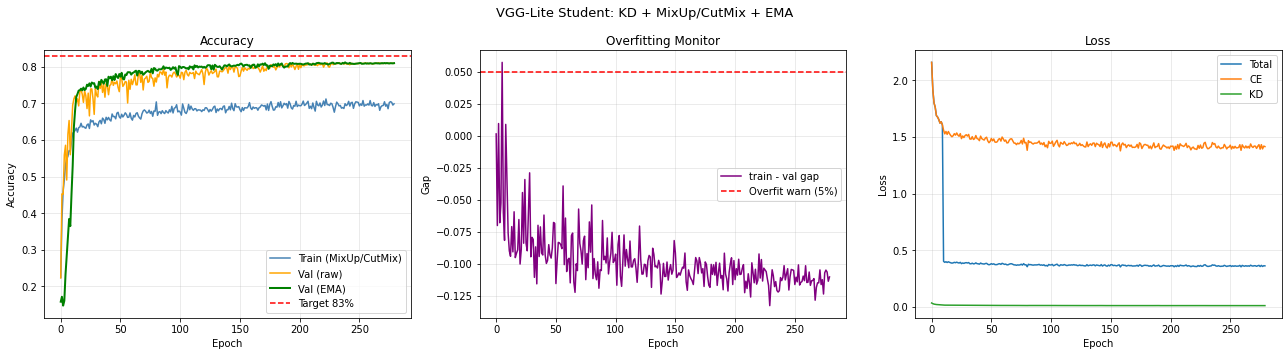

Final train-val gap: -0.1105
Overfitting risk: LOW — healthy


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['accuracy'], label='Train (MixUp/CutMix)', color='steelblue')
axes[0].plot(history['val_accuracy'], label='Val (raw)', color='orange')
axes[0].plot(history['ema_val_accuracy'], label='Val (EMA)', color='green', lw=2)
axes[0].axhline(0.83, color='red', ls='--', label='Target 83%')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_val_gap'], label='train - val gap', color='purple')
axes[1].axhline(0.05, color='red', ls='--', label='Overfit warn (5%)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Gap'); axes[1].set_title('Overfitting Monitor')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['loss'], label='Total')
axes[2].plot(history['ce_loss'], label='CE')
axes[2].plot(history['kd_loss'], label='KD')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss'); axes[2].set_title('Loss')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('VGG-Lite Student: KD + MixUp/CutMix + EMA', fontsize=13)
plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
gap_final = history['train_val_gap'][-1]
print(f'Final train-val gap: {gap_final:.4f}')
print(f'Overfitting risk: {"HIGH" if gap_final > 0.05 else "LOW — healthy"}')

## 7. Evaluation & Overfitting Check

Teacher val accuracy : 0.8848 (88.48%)
Student val accuracy : 0.8105 (81.05%)
Student val loss     : 1.1689


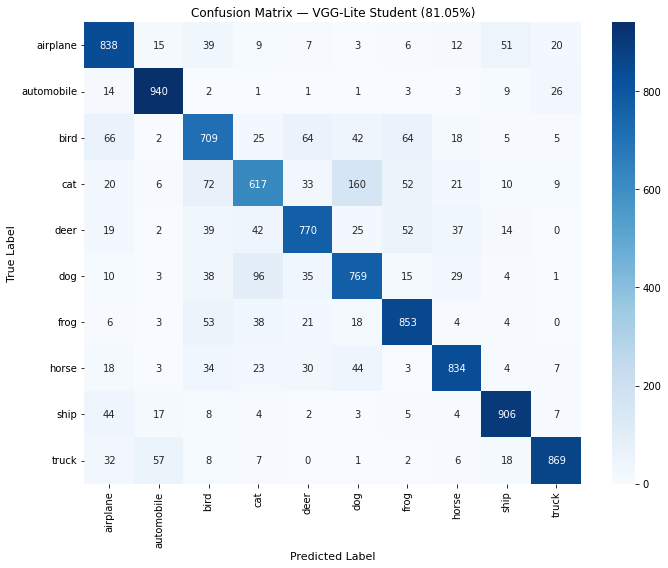


Classification Report:
              precision    recall  f1-score   support

    airplane       0.79      0.84      0.81      1000
  automobile       0.90      0.94      0.92      1000
        bird       0.71      0.71      0.71      1000
         cat       0.72      0.62      0.66      1000
        deer       0.80      0.77      0.78      1000
         dog       0.72      0.77      0.74      1000
        frog       0.81      0.85      0.83      1000
       horse       0.86      0.83      0.85      1000
        ship       0.88      0.91      0.89      1000
       truck       0.92      0.87      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



In [8]:
best_model = keras.models.load_model('model_fp32.h5')
teacher_eval = keras.models.load_model('model_teacher.h5')
# val_ds uses one-hot labels (y_test_ohe) — match training loss
if '_compile_for_eval' not in globals():
    _eval_kw = dict(
        optimizer=keras.optimizers.SGD(),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    def _compile_for_eval(m):
        m.compile(**_eval_kw)
        return m
best_model = _compile_for_eval(best_model)
teacher_eval = _compile_for_eval(teacher_eval)

test_loss, test_acc = best_model.evaluate(val_ds, verbose=0)
_, teacher_acc = teacher_eval.evaluate(val_ds, verbose=0)
print(f'Teacher val accuracy : {teacher_acc:.4f} ({teacher_acc*100:.2f}%)')
print(f'Student val accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'Student val loss     : {test_loss:.4f}')

if test_acc < 0.83:
    print(
        f'WARNING: val accuracy {test_acc*100:.2f}% < 83% target. '
        'Increase EPOCHS_STUDENT to retrain; current checkpoint is still usable.'
    )
else:
    print('Target >= 83%: OK')

# Predictions
y_pred_probs = best_model.predict(val_ds, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = y_test.flatten()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
ax.set_title(f'Confusion Matrix — VGG-Lite Student ({test_acc*100:.2f}%)', fontsize=12)
plt.tight_layout()
plt.savefig('../results/confusion_matrix_fp32.png', dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

## 8. Save Models

In [9]:
os.makedirs('saved_model', exist_ok=True)
os.makedirs('../results', exist_ok=True)
best_model.save('saved_model/')
size_h5 = os.path.getsize('model_fp32.h5') / 1024
n_params = best_model.count_params()

_hist_path = '../results/train_history.json'
if 'history' in globals() and isinstance(history, dict):
    _hist = history
elif os.path.isfile(_hist_path):
    with open(_hist_path) as f:
        _hist = json.load(f)
else:
    _hist = None

if _hist:
    best_ema_val_acc = float(max(_hist['ema_val_accuracy']))
    final_train_val_gap = float(_hist['train_val_gap'][-1])
else:
    best_ema_val_acc = float(test_acc)
    final_train_val_gap = None

summary = {
    'model_name': 'VGG_Lite_Student',
    'architecture': '16-16 / 24-24 / 32-32 + GAP',
    'total_params': int(n_params),
    'test_accuracy': float(test_acc),
    'teacher_val_accuracy': float(teacher_acc),
    'best_ema_val_acc': best_ema_val_acc,
    'final_train_val_gap': final_train_val_gap,
    'strategy': 'KD+MixUp+CutMix+EMA+SGD-Cosine',
    'epochs_student': globals().get('EPOCHS_STUDENT', 200),
    'batch_size': globals().get('BATCH_SIZE', 128),
}
with open('../results/training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))
print(f'Saved: model_fp32.h5 ({size_h5:.1f} KB), model_teacher.h5, saved_model/')

2026-05-21 11:51:27.485383: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: saved_model/assets
{
  "model_name": "VGG_Lite_Student",
  "architecture": "16-16 / 24-24 / 32-32 + GAP",
  "total_params": 19450,
  "test_accuracy": 0.8105000257492065,
  "teacher_val_accuracy": 0.8848000168800354,
  "best_ema_val_acc": 0.8119066455696202,
  "final_train_val_gap": -0.1104953422235021,
  "strategy": "KD+MixUp+CutMix+EMA+SGD-Cosine",
  "epochs_student": 280,
  "batch_size": 128
}
Saved: model_fp32.h5 (141.7 KB), model_teacher.h5, saved_model/


## 9. Parameter Count Summary Table

In [10]:
import pandas as pd
import os

if 'best_model' not in globals():
    best_model = keras.models.load_model('model_fp32.h5')
total_params = best_model.count_params()

layer_info = []
for layer in best_model.layers:
    params = layer.count_params()
    if params > 0:
        layer_info.append({
            'Layer'      : layer.name,
            'Type'       : layer.__class__.__name__,
            'Output Shape': str(layer.output_shape),
            'Parameters' : f'{params:,}'
        })

df_layers = pd.DataFrame(layer_info)
print('Layer Parameter Summary:')
print(df_layers.to_string(index=False))
_ok = 'OK' if total_params < 100_000 else 'WARN (>100K)'
print(f'\nTotal: {total_params:,} parameters (<100K {_ok})')

os.makedirs('../results', exist_ok=True)
df_layers.to_csv('../results/model_layer_summary.csv', index=False)
print('Saved: ../results/model_layer_summary.csv')

Layer Parameter Summary:
      Layer               Type       Output Shape Parameters
     conv1a             Conv2D (None, 32, 32, 16)        432
  bn_conv1a BatchNormalization (None, 32, 32, 16)         64
     conv1b             Conv2D (None, 32, 32, 16)      2,304
  bn_conv1b BatchNormalization (None, 32, 32, 16)         64
     conv2a             Conv2D (None, 16, 16, 20)      2,880
  bn_conv2a BatchNormalization (None, 16, 16, 20)         80
     conv2b             Conv2D (None, 16, 16, 20)      3,600
  bn_conv2b BatchNormalization (None, 16, 16, 20)         80
     conv3a             Conv2D   (None, 8, 8, 24)      4,320
  bn_conv3a BatchNormalization   (None, 8, 8, 24)         96
     conv3b             Conv2D   (None, 8, 8, 24)      5,184
  bn_conv3b BatchNormalization   (None, 8, 8, 24)         96
predictions              Dense         (None, 10)        250

Total: 19,450 parameters (<100K OK)
Saved: ../results/model_layer_summary.csv
